# Stage 3 Localisation Fine-Tuning on FF++ C23
This notebook presents the fine-tuning stage of the semantic-region localisation model. The pretrained Stage 3 regional detector is adapted to FaceForensics++ C23 and evaluated both for classification performance and for qualitative localisation behaviour.

Unlike the non-localisation notebooks, this notebook includes region-level visual analysis because the model predicts both image-level fake/real labels and region-level manipulation evidence.


## 1. Import Libraries and Set Up Environment
This section imports the libraries required for preprocessing, mask generation, model fine-tuning, evaluation, and visualisation.


In [1]:
import os, random, warnings, shutil
from io import BytesIO
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
import torchvision.transforms.functional as TF

from tqdm import tqdm
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, roc_curve
from scipy.optimize import brentq
from scipy.interpolate import interp1d
from torch.optim.lr_scheduler import CosineAnnealingLR

warnings.filterwarnings("ignore")
device = "cuda" if torch.cuda.is_available() else "cpu"

## 2. Dataset Paths and Semantic Region Definition
This section defines the dataset paths, pretrained checkpoint path, and the 20 semantic facial regions used by the localisation model. These regions provide anatomically meaningful localisation rather than generic patch-based highlighting.


In [2]:


# -----------------------------
# Paths
# -----------------------------
FF_ALIGNED_ROOT = Path("/kaggle/input/datasets/hooriyamasood/ffpp-aligned-faces")
FF_MASK_ROOT    = Path("/kaggle/working/FF_semantic_masks_20r")
PRETRAINED_PTH  = "/kaggle/input/models/hooriyamasood/140k-best-weights-semantic-masks-20/pytorch/default/1/best_weights_pretrain (1).pth"   

# If your best pretrain weights are stored as a Kaggle input instead, use that full path instead.

# -----------------------------
# Region names
# -----------------------------
REGION_NAMES = [
    "full_face",          # 0
    "forehead_left",      # 1
    "forehead_center",    # 2
    "forehead_right",     # 3
    "left_eye",           # 4
    "right_eye",          # 5
    "left_eyebrow",       # 6
    "right_eyebrow",      # 7
    "nose_bridge",        # 8
    "nose_tip",           # 9
    "left_under_eye",     # 10
    "right_under_eye",    # 11
    "left_cheek_upper",   # 12
    "right_cheek_upper",  # 13
    "left_cheek_lower",   # 14
    "right_cheek_lower",  # 15
    "mouth_upper",        # 16
    "mouth_lower",        # 17
    "chin",               # 18
    "background"          # 19
]



## 3. Augmentation, Metrics, and Helper Functions
This section defines data augmentation, evaluation metrics, frequency filtering, mask resizing, denormalisation, and the MIL-style region loss used during fine-tuning.


In [3]:
# -----------------------------
# JPEG augmentation
# -----------------------------
class RandomJPEG:
    def __init__(self, quality_min=60, quality_max=95, p=0.3):
        self.quality_min = quality_min
        self.quality_max = quality_max
        self.p = p

    def __call__(self, img: Image.Image):
        if random.random() > self.p:
            return img
        q = random.randint(self.quality_min, self.quality_max)
        buf = BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

# -----------------------------
# Metrics
# -----------------------------
def calc_metrics(y_true_fake01, y_prob_fake):
    y_pred_fake = (y_prob_fake > 0.5).astype(np.int32)

    auc = roc_auc_score(y_true_fake01, y_prob_fake)
    f1 = f1_score(y_true_fake01, y_pred_fake)
    acc = accuracy_score(y_true_fake01, y_pred_fake)

    fpr, tpr, _ = roc_curve(y_true_fake01, y_prob_fake)
    eer = brentq(lambda x: 1. - x - interp1d(fpr, tpr)(x), 0., 1.)

    return auc, f1, eer, acc

# -----------------------------
# Frequency branch
# -----------------------------
class GlobalFilter(nn.Module):
    def __init__(self, dim, h, w, fp32fft=True):
        super().__init__()
        self.h = h
        self.w = w
        self.fp32fft = fp32fft
        self.complex_weight = nn.Parameter(
            torch.randn(h, w // 2 + 1, dim, 2, dtype=torch.float32) * 0.02
        )

    def forward(self, x):
        B, C, H, W = x.shape
        assert H == self.h and W == self.w, f"Expected {self.h}x{self.w}, got {H}x{W}"

        x = x.permute(0, 2, 3, 1).contiguous()

        if self.fp32fft:
            orig_dtype = x.dtype
            x = x.float()

        x_f = torch.fft.rfft2(x, dim=(1, 2), norm="ortho")
        w = torch.view_as_complex(self.complex_weight)
        x_f = x_f * w
        x = torch.fft.irfft2(x_f, s=(H, W), dim=(1, 2), norm="ortho")

        if self.fp32fft:
            x = x.to(orig_dtype)

        x = x.permute(0, 3, 1, 2).contiguous()
        return x

# -----------------------------
# Mask helpers
# -----------------------------
def resize_masks_to_feature_torch(masks, h, w):
    return F.interpolate(
        masks,
        size=(h, w),
        mode="bilinear",
        align_corners=False
    )

def masked_avg_pool_batch(feat, masks):
    feat_e = feat.unsqueeze(1)   # [B,1,C,H,W]
    masks_e = masks.unsqueeze(2) # [B,R,1,H,W]

    weighted = feat_e * masks_e
    denom = masks_e.sum(dim=(-1, -2)).clamp_min(1e-6)
    pooled = weighted.sum(dim=(-1, -2)) / denom
    return pooled

def denorm_rgb_tensor(x):
    mean = torch.tensor([0.485, 0.456, 0.406], device=x.device).view(3,1,1)
    std = torch.tensor([0.229, 0.224, 0.225], device=x.device).view(3,1,1)
    y = (x * std) + mean
    y = y.clamp(0, 1)
    return y.permute(1,2,0).detach().cpu().numpy()

# -----------------------------
# MIL region loss
# -----------------------------
def mil_region_loss(region_logits, lbls, fake_idx, bg_idx, topk_frac=0.25):
    reg_fake_logit = region_logits[:, :, fake_idx]

    # exclude full_face (0) and background (bg_idx)
    face_logits = reg_fake_logit[:, 1:bg_idx]

    k = max(1, int(face_logits.size(1) * topk_frac))
    topk_vals, _ = torch.topk(face_logits, k=k, dim=1)
    face_topk = topk_vals.mean(dim=1)

    target_fake = (lbls == fake_idx).float()
    loss_mil = F.binary_cross_entropy_with_logits(face_topk, target_fake)

    bg_logit = reg_fake_logit[:, bg_idx]
    loss_bg = F.binary_cross_entropy_with_logits(
        bg_logit,
        torch.zeros_like(bg_logit)
    )

    return loss_mil, loss_bg

# -----------------------------
# Model (same as pretrain)
# -----------------------------
class Model(nn.Module):
    def __init__(self, embed_dim=512, num_heads=8, num_layers=4, use_fft=True, num_regions=20):
        super().__init__()
        self.use_fft = use_fft
        self.num_regions = num_regions

        self.freq_filter = GlobalFilter(dim=512, h=28, w=28, fp32fft=True)

        resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.stem = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool)
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        self.proj_rgb = nn.Conv2d(2048, embed_dim, 1)
        self.proj_fft = nn.Conv2d(512, embed_dim, 1)

        self.region_fuse = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, embed_dim)
        )

        self.gate_fc = nn.Sequential(
            nn.Linear(embed_dim * 2, embed_dim),
            nn.GELU(),
            nn.Linear(embed_dim, 1)
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            batch_first=True,
            norm_first=True
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, 1 + num_regions, embed_dim))

        self.cls_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

        self.region_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, 2)
        )

    def forward(self, x_rgb, x_raw, masks, return_regions=False, return_aux=False):
        B = x_rgb.size(0)

        x = self.stem(x_rgb)
        x = self.layer1(x)
        feat_l2 = self.layer2(x)
        x = self.layer3(feat_l2)
        feat_l4 = self.layer4(x)

        rgb_map = self.proj_rgb(feat_l4)

        if self.use_fft:
            fft_feat = self.freq_filter(feat_l2)
            fft_map = self.proj_fft(fft_feat)
        else:
            fft_map = torch.zeros(
                B, rgb_map.shape[1], feat_l2.shape[2], feat_l2.shape[3],
                device=x_rgb.device
            )

        rgb_masks = resize_masks_to_feature_torch(masks, rgb_map.shape[2], rgb_map.shape[3])
        fft_masks = resize_masks_to_feature_torch(masks, fft_map.shape[2], fft_map.shape[3])

        rgb_tokens = masked_avg_pool_batch(rgb_map, rgb_masks)
        fft_tokens = masked_avg_pool_batch(fft_map, fft_masks)

        region_local = self.region_fuse(torch.cat([rgb_tokens, fft_tokens], dim=-1))

        cls_seed = region_local[:, 0:1, :]
        cls = self.cls_token.expand(B, -1, -1) + cls_seed

        cls_rep = cls.expand(-1, self.num_regions, -1)
        gate_in = torch.cat([region_local, cls_rep], dim=-1)
        alpha = torch.sigmoid(self.gate_fc(gate_in))

        region_tokens = alpha * region_local + (1.0 - alpha) * cls_rep

        tokens = torch.cat([cls, region_tokens], dim=1)
        tokens = tokens + self.pos_embed[:, :tokens.size(1), :]

        out = self.transformer(tokens)
        cls_out = out[:, 0]
        region_out = out[:, 1:]

        image_logits = self.cls_head(cls_out)
        region_logits = self.region_head(region_out)

        if not return_regions and not return_aux:
            return image_logits
        if return_regions and not return_aux:
            return image_logits, region_logits

        aux = {
            "alpha": alpha,
            "masks": masks
        }
        return image_logits, region_logits, aux

print("Cell 1 loaded.")

Cell 1 loaded.


## 4. Semantic Face Mask Generation
Semantic masks are generated using MediaPipe Face Mesh landmarks. Each face is divided into 20 interpretable regions such as eyes, cheeks, nose, mouth, chin, and background.

If facial landmarks are not detected, a fallback geometric face prior is used so that every image still receives a valid regional mask.


In [4]:
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.14 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 20.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
a2a-sdk 0.3.22 requires protobuf>=5.29.5, but you have protobuf 4.25.9 which is incompatible.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.9 which is incompatible.
ydf 0.13.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 4.25.9 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.9 whic

In [5]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh

_FACE_MESH = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

def get_face_mesh_points(img01):
    H, W = img01.shape[:2]
    img_u8 = (img01 * 255).astype(np.uint8)
    res = _FACE_MESH.process(img_u8)

    if not res.multi_face_landmarks:
        return None

    lm = res.multi_face_landmarks[0]
    pts = []
    for p in lm.landmark:
        x = int(np.clip(p.x * W, 0, W - 1))
        y = int(np.clip(p.y * H, 0, H - 1))
        pts.append([x, y])
    return np.array(pts, dtype=np.int32)

def polygon_mask_from_points(shape_hw, pts, idxs):
    H, W = shape_hw
    mask = np.zeros((H, W), dtype=np.uint8)

    poly = pts[np.array(idxs, dtype=np.int32)]
    if poly.shape[0] < 3:
        return mask.astype(np.float32)

    cv2.fillConvexPoly(mask, poly, 255)
    mask = cv2.GaussianBlur(mask, (7, 7), 0)
    return (mask > 127).astype(np.float32)

def build_semantic_face_masks(img01):
    H, W = img01.shape[:2]
    pts = get_face_mesh_points(img01)

    yy, xx = np.mgrid[0:H, 0:W]
    xnorm = xx / float(W)
    ynorm = yy / float(H)

    if pts is None:
        used_fallback = 1

        cx, cy = W / 2.0, H / 2.0
        full = ((((xx-cx)/(W*0.33))**2 + ((yy-cy)/(H*0.42))**2) <= 1.0).astype(np.float32)

        forehead_left   = full * (ynorm < 0.28) * (xnorm < 0.43)
        forehead_center = full * (ynorm < 0.28) * (xnorm >= 0.43) * (xnorm <= 0.57)
        forehead_right  = full * (ynorm < 0.28) * (xnorm > 0.57)

        left_eye       = full * (ynorm > 0.28) * (ynorm < 0.42) * (xnorm > 0.22) * (xnorm < 0.45)
        right_eye      = full * (ynorm > 0.28) * (ynorm < 0.42) * (xnorm > 0.55) * (xnorm < 0.78)

        left_eyebrow   = full * (ynorm > 0.20) * (ynorm < 0.30) * (xnorm > 0.22) * (xnorm < 0.45)
        right_eyebrow  = full * (ynorm > 0.20) * (ynorm < 0.30) * (xnorm > 0.55) * (xnorm < 0.78)

        nose_bridge = full * (ynorm > 0.28) * (ynorm < 0.52) * (xnorm > 0.44) * (xnorm < 0.56)
        nose_tip    = full * (ynorm > 0.52) * (ynorm < 0.63) * (xnorm > 0.40) * (xnorm < 0.60)

        left_under_eye  = full * (ynorm > 0.40) * (ynorm < 0.52) * (xnorm > 0.22) * (xnorm < 0.45)
        right_under_eye = full * (ynorm > 0.40) * (ynorm < 0.52) * (xnorm > 0.55) * (xnorm < 0.78)

        left_cheek_upper  = full * (ynorm > 0.48) * (ynorm < 0.62) * (xnorm > 0.15) * (xnorm < 0.42)
        right_cheek_upper = full * (ynorm > 0.48) * (ynorm < 0.62) * (xnorm > 0.58) * (xnorm < 0.85)

        left_cheek_lower  = full * (ynorm > 0.62) * (ynorm < 0.76) * (xnorm > 0.15) * (xnorm < 0.45)
        right_cheek_lower = full * (ynorm > 0.62) * (ynorm < 0.76) * (xnorm > 0.55) * (xnorm < 0.85)

        mouth_upper = full * (ynorm > 0.62) * (ynorm < 0.70) * (xnorm > 0.35) * (xnorm < 0.65)
        mouth_lower = full * (ynorm > 0.70) * (ynorm < 0.79) * (xnorm > 0.35) * (xnorm < 0.65)

        chin = full * (ynorm > 0.78)
        bg = 1.0 - full

        masks = np.stack([
            full,
            forehead_left, forehead_center, forehead_right,
            left_eye, right_eye,
            left_eyebrow, right_eyebrow,
            nose_bridge, nose_tip,
            left_under_eye, right_under_eye,
            left_cheek_upper, right_cheek_upper,
            left_cheek_lower, right_cheek_lower,
            mouth_upper, mouth_lower,
            chin,
            bg
        ], axis=0).astype(np.float32)

        return masks, used_fallback

    used_fallback = 0

    face_oval = [10,338,297,332,284,251,389,356,454,323,361,288,397,365,
                 379,378,400,377,152,148,176,149,150,136,172,58,132,93,
                 234,127,162,21,54,103,67,109]

    left_eye_idx = [33,133,160,159,158,157,173,153,144,145]
    right_eye_idx = [362,263,387,386,385,384,398,373,374,380]
    mouth_idx = [61,146,91,181,84,17,314,405,321,375,291]
    nose_idx = [6,197,195,5,4,1,19,94,2,98,327]

    face_f = polygon_mask_from_points((H, W), pts, face_oval)
    le_f   = polygon_mask_from_points((H, W), pts, left_eye_idx)
    re_f   = polygon_mask_from_points((H, W), pts, right_eye_idx)
    mo_f   = polygon_mask_from_points((H, W), pts, mouth_idx)
    no_f   = polygon_mask_from_points((H, W), pts, nose_idx)

    forehead_left   = face_f * (ynorm < 0.28) * (xnorm < 0.43)
    forehead_center = face_f * (ynorm < 0.28) * (xnorm >= 0.43) * (xnorm <= 0.57)
    forehead_right  = face_f * (ynorm < 0.28) * (xnorm > 0.57)

    left_eyebrow   = face_f * (ynorm > 0.18) * (ynorm < 0.28) * (xnorm > 0.20) * (xnorm < 0.46)
    right_eyebrow  = face_f * (ynorm > 0.18) * (ynorm < 0.28) * (xnorm > 0.54) * (xnorm < 0.80)

    nose_bridge = no_f * (ynorm < 0.52)
    nose_tip    = no_f * (ynorm >= 0.52)

    left_under_eye  = face_f * (ynorm > 0.40) * (ynorm < 0.52) * (xnorm > 0.20) * (xnorm < 0.46)
    right_under_eye = face_f * (ynorm > 0.40) * (ynorm < 0.52) * (xnorm > 0.54) * (xnorm < 0.80)

    left_cheek_upper  = face_f * (ynorm > 0.48) * (ynorm < 0.62) * (xnorm > 0.12) * (xnorm < 0.42)
    right_cheek_upper = face_f * (ynorm > 0.48) * (ynorm < 0.62) * (xnorm > 0.58) * (xnorm < 0.88)

    left_cheek_lower  = face_f * (ynorm > 0.62) * (ynorm < 0.76) * (xnorm > 0.12) * (xnorm < 0.46)
    right_cheek_lower = face_f * (ynorm > 0.62) * (ynorm < 0.76) * (xnorm > 0.54) * (xnorm < 0.88)

    mouth_upper = mo_f * (ynorm < 0.71)
    mouth_lower = mo_f * (ynorm >= 0.71)

    chin = face_f * (ynorm > 0.78)
    bg = 1.0 - face_f

    masks = np.stack([
        face_f,
        forehead_left, forehead_center, forehead_right,
        le_f, re_f,
        left_eyebrow, right_eyebrow,
        nose_bridge, nose_tip,
        left_under_eye, right_under_eye,
        left_cheek_upper, right_cheek_upper,
        left_cheek_lower, right_cheek_lower,
        mouth_upper, mouth_lower,
        chin,
        bg
    ], axis=0).astype(np.float32)

    masks = np.clip(masks, 0.0, 1.0)
    return masks, used_fallback

def save_mask_file(img_path: Path, out_path: Path):
    img = Image.open(img_path).convert("RGB")
    img = np.array(img).astype(np.float32) / 255.0

    masks, used_fallback = build_semantic_face_masks(img)

    masks_small = np.stack([
        cv2.resize(m, (112, 112), interpolation=cv2.INTER_NEAREST)
        for m in masks
    ])

    out_path.parent.mkdir(parents=True, exist_ok=True)

    np.savez_compressed(
        out_path,
        masks=(masks_small * 255).astype(np.uint8),
        fallback=np.array([used_fallback], dtype=np.uint8)
    )

def generate_masks(ff_root: Path, mask_root: Path, show_progress=True):

    if mask_root.exists():
        shutil.rmtree(mask_root)
    mask_root.mkdir(parents=True, exist_ok=True)

    saved = 0
    failed = 0
    fail_examples = []

    splits = ["train", "val", "test"]
    manips = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]

    for split in splits:
        # real
        real_src = ff_root / split / "real"
        for video_dir in tqdm(sorted(real_src.iterdir()), desc=f"{split}/real", disable=not show_progress):

            if not video_dir.is_dir():
                continue
            for img_path in sorted(video_dir.glob("*")):
                if img_path.is_file():
                    rel = img_path.relative_to(ff_root / split)
                    out_path = mask_root / split / rel.parent / f"{img_path.stem}.npz"
                    try:
                        save_mask_file(img_path, out_path)
                        saved += 1
                    except Exception as e:
                        failed += 1
                        if len(fail_examples) < 20:
                            fail_examples.append((str(img_path), repr(e)))

        # fake
        fake_src = ff_root / split / "fake"
        for manip in manips:
            manip_dir = fake_src / manip
            if not manip_dir.exists():
                print(f"Missing manip dir: {manip_dir}")
                continue
            for video_dir in tqdm(sorted(manip_dir.iterdir()), desc=f"{split}/{manip}", disable=not show_progress):
           
                if not video_dir.is_dir():
                    continue
                for img_path in sorted(video_dir.glob("*")):
                    if img_path.is_file():
                        rel = img_path.relative_to(ff_root / split)
                        out_path = mask_root / split / rel.parent / f"{img_path.stem}.npz"
                        try:
                            save_mask_file(img_path, out_path)
                            saved += 1
                        except Exception as e:
                            failed += 1
                            if len(fail_examples) < 20:
                                fail_examples.append((str(img_path), repr(e)))

    print("Saved:", saved)
    print("Failed:", failed)
    print("Sample failures:", fail_examples[:5])

generate_masks(FF_ALIGNED_ROOT, FF_MASK_ROOT, show_progress=False)

2026-04-26 11:25:50.931303: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777202751.161227      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777202751.222274      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777202751.782567      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777202751.782606      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777202751.782608      22 computation_placer.cc:177] computation placer alr

Saved: 50000
Failed: 0
Sample failures: []


## 6. Dataset Construction
This dataset returns:
- RGB input
- raw input
- semantic masks
- class label

During training, horizontal flips and JPEG augmentation are applied consistently to both images and masks so that localisation supervision remains aligned.


In [6]:
class FFPPMaskDataset(Dataset):
    """
    Returns:
        x_rgb, x_raw, masks_t, y

    Label convention kept consistent with pretrain:
        fake = 0
        real = 1
    """
    def __init__(self, img_root, mask_root, train=True,
             p_flip=0.5, jpeg_aug=None, rgb_color_aug=None, rgb_norm=None,
             verbose=True):

        self.img_root = Path(img_root)
        self.mask_root = Path(mask_root)
        self.train = train
        self.p_flip = p_flip
        self.jpeg_aug = jpeg_aug
        self.rgb_color_aug = rgb_color_aug
        self.rgb_norm = rgb_norm
        self.verbose = verbose


        self.class_to_idx = {"fake": 0, "real": 1}
        self.samples = []

        # real videos
        real_root = self.img_root / "real"
        for vid_dir in sorted(real_root.glob("*")):
            if not vid_dir.is_dir():
                continue
            for img_path in sorted(vid_dir.glob("*")):
                if img_path.is_file():
                    self.samples.append((img_path, self.class_to_idx["real"], "real"))

        # fake videos
        fake_root = self.img_root / "fake"
        manips = ["Deepfakes", "Face2Face", "FaceSwap", "NeuralTextures"]
        for manip in manips:
            manip_root = fake_root / manip
            if not manip_root.exists():
                continue
            for vid_dir in sorted(manip_root.glob("*")):
                if not vid_dir.is_dir():
                    continue
                for img_path in sorted(vid_dir.glob("*")):
                    if img_path.is_file():
                        self.samples.append((img_path, self.class_to_idx["fake"], manip))

        if self.verbose:
            print(f"[FFPPMaskDataset] {self.img_root}")
            print("samples:", len(self.samples))
            print("fake:", sum(y == self.class_to_idx["fake"] for _, y, _ in self.samples))
            print("real:", sum(y == self.class_to_idx["real"] for _, y, _ in self.samples))


    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        img_path, y, manip = self.samples[index]

        rel = img_path.relative_to(self.img_root)
        mask_path = self.mask_root / rel.parent / f"{img_path.stem}.npz"

        img = Image.open(img_path).convert("RGB")
        masks = np.load(mask_path)["masks"].astype(np.float32) / 255.0

        do_flip = self.train and (random.random() < self.p_flip)
        if do_flip:
            img = TF.hflip(img)
            masks = np.flip(masks, axis=2).copy()
        
            # swap left/right regions
            swap_pairs = [
                (1, 3),    # forehead_left <-> forehead_right
                (4, 5),    # left_eye <-> right_eye
                (6, 7),    # left_eyebrow <-> right_eyebrow
                (10, 11),  # left_under_eye <-> right_under_eye
                (12, 13),  # left_cheek_upper <-> right_cheek_upper
                (14, 15),  # left_cheek_lower <-> right_cheek_lower
            ]
        
            for a, b in swap_pairs:
                masks[[a, b]] = masks[[b, a]]

        img_jpeg = self.jpeg_aug(img) if (self.train and self.jpeg_aug is not None) else img

        x_raw = TF.to_tensor(img_jpeg)

        img_rgb = self.rgb_color_aug(img_jpeg) if (self.train and self.rgb_color_aug is not None) else img_jpeg
        x_rgb = TF.to_tensor(img_rgb)
        if self.rgb_norm is not None:
            x_rgb = self.rgb_norm(x_rgb)

        masks_t = torch.tensor(masks, dtype=torch.float32)
        return x_rgb, x_raw, masks_t, y

def make_frame_sampler(dataset):
    """
    Balances fake vs real at frame level.
    """
    labels = [y for _, y, _ in dataset.samples]
    class_counts = {}
    for y in labels:
        class_counts[y] = class_counts.get(y, 0) + 1

    weights = [1.0 / class_counts[y] for y in labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

# quick check
rgb_norm = transforms.Normalize([0.485, 0.456, 0.406],
                                [0.229, 0.224, 0.225])

tmp_ds = FFPPMaskDataset(
    img_root=FF_ALIGNED_ROOT / "train",
    mask_root=FF_MASK_ROOT / "train",
    train=True,
    p_flip=0.5,
    jpeg_aug=None,
    rgb_color_aug=None,
    rgb_norm=rgb_norm,
    verbose=False
)

x_rgb, x_raw, masks_t, y = tmp_ds[0]
print("x_rgb:", x_rgb.shape, x_rgb.dtype)
print("x_raw:", x_raw.shape, x_raw.dtype)
print("masks:", masks_t.shape, masks_t.dtype, masks_t.min().item(), masks_t.max().item())
print("label:", y)
print("class_to_idx:", tmp_ds.class_to_idx)

x_rgb: torch.Size([3, 224, 224]) torch.float32
x_raw: torch.Size([3, 224, 224]) torch.float32
masks: torch.Size([20, 112, 112]) torch.float32 0.0 1.0
label: 1
class_to_idx: {'fake': 0, 'real': 1}


## 7. Localisation Fine-Tuning Configuration
The pretrained regional model is fine-tuned on FF++ C23. Image-level classification loss is combined with:
- a MIL-based region loss over facial regions
- a background suppression loss

This encourages the model to classify fakes correctly while also focusing attention on meaningful manipulated facial regions.


In [7]:
def finetune(
    pretrained_ckpt_path,
    ff_img_root,
    ff_mask_root,
    epochs=15,
    freeze_epochs=1,
    batch_size=16
):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model = Model(use_fft=True, num_regions=20).to(device)

    # load pretrained weights
    state = torch.load(pretrained_ckpt_path, map_location="cpu")
    model.load_state_dict(state, strict=True)
    print("Loaded pretrained:", pretrained_ckpt_path)

    # augs
    jpeg_aug = RandomJPEG(quality_min=60, quality_max=95, p=0.3)
    rgb_color_aug = transforms.Compose([
        transforms.ColorJitter(0.08, 0.08, 0.04, 0.02),
    ])
    rgb_norm = transforms.Normalize([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])

    trainset = FFPPMaskDataset(
        img_root=Path(ff_img_root) / "train",
        mask_root=Path(ff_mask_root) / "train",
        train=True,
        p_flip=0.5,
        jpeg_aug=jpeg_aug,
        rgb_color_aug=rgb_color_aug,
        rgb_norm=rgb_norm
    )

    valset = FFPPMaskDataset(
        img_root=Path(ff_img_root) / "val",
        mask_root=Path(ff_mask_root) / "val",
        train=False,
        p_flip=0.0,
        jpeg_aug=None,
        rgb_color_aug=None,
        rgb_norm=rgb_norm,
        verbose=False
    )

    testset = FFPPMaskDataset(
        img_root=Path(ff_img_root) / "test",
        mask_root=Path(ff_mask_root) / "test",
        train=False,
        p_flip=0.0,
        jpeg_aug=None,
        rgb_color_aug=None,
        rgb_norm=rgb_norm,
        verbose=False
    )



    sampler = make_frame_sampler(trainset)

    trainloader = DataLoader(trainset, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
    valloader   = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    testloader  = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    class_to_idx = trainset.class_to_idx
    fake_idx = class_to_idx["fake"]
    bg_idx = 19

    print("class_to_idx:", class_to_idx)

    # lower LR backbone, higher LR heads
    backbone_params = (
        list(model.stem.parameters()) +
        list(model.layer1.parameters()) +
        list(model.layer2.parameters()) +
        list(model.layer3.parameters()) +
        list(model.layer4.parameters())
    )

    head_param_names = (
        "freq_filter", "proj_rgb", "proj_fft",
        "region_fuse", "gate_fc", "transformer",
        "cls_token", "pos_embed", "cls_head", "region_head"
    )

    head_params = []
    for n, p in model.named_parameters():
        if any(n.startswith(prefix) for prefix in head_param_names):
            head_params.append(p)

    opt = torch.optim.AdamW([
        {"params": backbone_params, "lr": 1e-5},
        {"params": head_params,     "lr": 5e-5},
    ], weight_decay=1e-4)

    scheduler = CosineAnnealingLR(opt, T_max=epochs)
    scaler = torch.amp.GradScaler(enabled=torch.cuda.is_available())

    criterion_img = nn.CrossEntropyLoss(label_smoothing=0.05)

    lambda_mil = 0.20
    lambda_bg = 0.10

    best_auc = -1.0
    use_cuda = torch.cuda.is_available()

    # ---- store training history for plots ----
    train_loss_list = []
    train_img_loss_list = []
    train_mil_loss_list = []
    train_bg_loss_list = []

    val_auc_list = []
    val_f1_list = []
    val_acc_list = []
    val_eer_list = []

    lr_backbone_list = []
    lr_head_list = []


    for epoch in range(epochs):
        # freeze backbone for warmup
        if epoch < freeze_epochs:
            for p in backbone_params:
                p.requires_grad = False
        else:
            for p in backbone_params:
                p.requires_grad = True

        model.train()
        running_loss = 0.0
        running_img = 0.0
        running_mil = 0.0
        running_bg = 0.0

        for x_rgb, x_raw, masks, lbls in tqdm(trainloader, desc=f"FT {epoch+1}/{epochs}", ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            lbls  = lbls.to(device, non_blocking=True)

            opt.zero_grad(set_to_none=True)

            with torch.amp.autocast(device_type="cuda", enabled=use_cuda):
                image_logits, region_logits, aux = model(
                    x_rgb, x_raw, masks,
                    return_regions=True,
                    return_aux=True
                )

                loss_img = criterion_img(image_logits, lbls)
                loss_mil, loss_bg = mil_region_loss(
                    region_logits, lbls,
                    fake_idx=fake_idx, bg_idx=bg_idx, topk_frac=0.25
                )

                loss = (
                    loss_img
                    + lambda_mil * loss_mil
                    + lambda_bg * loss_bg
                )

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(opt)
            scaler.update()

            running_loss += float(loss.item())
            running_img += float(loss_img.item())
            running_mil += float(loss_mil.item())
            running_bg += float(loss_bg.item())

        # validation
        model.eval()
        y_true, y_prob = [], []

        with torch.no_grad():
            for x_rgb, x_raw, masks, lbls in valloader:
                x_rgb = x_rgb.to(device, non_blocking=True)
                x_raw = x_raw.to(device, non_blocking=True)
                masks = masks.to(device, non_blocking=True)

                logits = model(x_rgb, x_raw, masks)
                probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

                lbls_np = lbls.numpy()
                y_true.extend((lbls_np == fake_idx).astype(np.int32))
                y_prob.extend(probs_fake)

        auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))

        train_loss_list.append(running_loss / len(trainloader))
        train_img_loss_list.append(running_img / len(trainloader))
        train_mil_loss_list.append(running_mil / len(trainloader))
        train_bg_loss_list.append(running_bg / len(trainloader))

        val_auc_list.append(auc)
        val_f1_list.append(f1)
        val_acc_list.append(acc)
        val_eer_list.append(eer)

        lr_backbone_list.append(opt.param_groups[0]["lr"])
        lr_head_list.append(opt.param_groups[1]["lr"])

        print(
            f"Epoch {epoch+1}: "
            f"loss={running_loss/len(trainloader):.4f} | "
            f"img={running_img/len(trainloader):.4f} | "
            f"mil={running_mil/len(trainloader):.4f} | "
            f"bg={running_bg/len(trainloader):.4f} | "
            f"AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}"
        )
        print("LRs:", [pg["lr"] for pg in opt.param_groups])

        scheduler.step()


        if auc > best_auc:
            best_auc = auc
            torch.save(model.state_dict(), "/kaggle/working/best_ffpp_mask_finetune.pth")
            print(f"★ New best AUC {best_auc:.3f}")

    print("\nLoading best fine-tuned model for test...")
    model.load_state_dict(torch.load("/kaggle/working/best_ffpp_mask_finetune.pth", map_location=device))

    # final test
    model.eval()
    y_true, y_prob = [], []
    with torch.no_grad():
        for x_rgb, x_raw, masks, lbls in tqdm(testloader, desc="FF++ TEST", ncols=100):
            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(x_rgb, x_raw, masks)
            probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

            lbls_np = lbls.numpy()
            y_true.extend((lbls_np == fake_idx).astype(np.int32))
            y_prob.extend(probs_fake)

    auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
    print(f"FF++ TEST → AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")

    return (
        model,
        trainloader,
        valloader,
        testloader,
        class_to_idx,
        train_loss_list,
        train_img_loss_list,
        train_mil_loss_list,
        train_bg_loss_list,
        val_auc_list,
        val_f1_list,
        val_acc_list,
        val_eer_list,
        lr_backbone_list,
        lr_head_list,
        auc,
        f1,
        eer,
        acc,
    )


## 8. Fine-Tuning on FF++ C23
This section runs fine-tuning on FF++ C23 and selects the best checkpoint using validation AUROC.


In [8]:
(
    model_ft,
    trainloader_ft,
    valloader_ft,
    testloader_ft,
    class_to_idx_ft,
    train_loss_list,
    train_img_loss_list,
    train_mil_loss_list,
    train_bg_loss_list,
    val_auc_list,
    val_f1_list,
    val_acc_list,
    val_eer_list,
    lr_backbone_list,
    lr_head_list,
    test_auc,
    test_f1,
    test_eer,
    test_acc,
) = finetune(
    pretrained_ckpt_path=PRETRAINED_PTH,
    ff_img_root=FF_ALIGNED_ROOT,
    ff_mask_root=FF_MASK_ROOT,
    epochs=15,
    freeze_epochs=1,
    batch_size=16
)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 187MB/s]


Loaded pretrained: /kaggle/input/models/hooriyamasood/140k-best-weights-semantic-masks-20/pytorch/default/1/best_weights_pretrain (1).pth
[FFPPMaskDataset] /kaggle/input/datasets/hooriyamasood/ffpp-aligned-faces/train
samples: 40000
fake: 32000
real: 8000
class_to_idx: {'fake': 0, 'real': 1}


FT 1/15: 100%|██████████████████████████████████████████████████| 2500/2500 [04:35<00:00,  9.08it/s]


Epoch 1: loss=0.8601 | img=0.7105 | mil=0.7471 | bg=0.0020 | AUROC=0.534 | F1=0.841 | EER=0.467 | ACC=0.734
LRs: [1e-05, 5e-05]
★ New best AUC 0.534


...

Epoch 14: loss=0.3194 | img=0.2655 | mil=0.2695 | bg=0.0000 | AUROC=0.861 | F1=0.928 | EER=0.162 | ACC=0.887
LRs: [4.3227271178699523e-07, 2.161363558934976e-06]


FT 15/15: 100%|█████████████████████████████████████████████████| 2500/2500 [05:01<00:00,  8.28it/s]


Epoch 15: loss=0.3184 | img=0.2648 | mil=0.2680 | bg=0.0000 | AUROC=0.854 | F1=0.932 | EER=0.177 | ACC=0.891
LRs: [1.092619963309716e-07, 5.46309981654858e-07]

Loading best fine-tuned model for test...


FF++ TEST: 100%|██████████████████████████████████████████████████| 313/313 [00:21<00:00, 14.44it/s]

FF++ TEST → AUROC=0.917 | F1=0.915 | EER=0.155 | ACC=0.867


## 9. Training Curves
The following plots summarise training behaviour during localisation fine-tuning, including overall loss, image loss, MIL loss, background loss, validation metrics, and learning rate scheduling.


In [9]:
import matplotlib.pyplot as plt

def plot_loc(
    train_loss,
    train_img_loss,
    train_mil_loss,
    train_bg_loss,
    val_auc,
    val_f1,
    val_acc,
    val_eer,
    lr_backbone,
    lr_head
):
    epochs = range(1, len(train_loss) + 1)

    plt.figure(figsize=(7,4))
    plt.plot(epochs, train_loss, marker='o', label='Total Loss')
    plt.plot(epochs, train_img_loss, marker='s', label='Image Loss')
    plt.plot(epochs, train_mil_loss, marker='^', label='MIL Loss')
    plt.plot(epochs, train_bg_loss, marker='d', label='BG Loss')
    plt.title("Training Loss Breakdown")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_auc, marker='o', label='AUROC')
    plt.plot(epochs, val_f1, marker='s', label='F1')
    plt.plot(epochs, val_acc, marker='^', label='Accuracy')
    plt.title("Validation Metrics")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, val_eer, marker='o', color='red')
    plt.title("Validation EER")
    plt.xlabel("Epoch")
    plt.ylabel("EER")
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7,4))
    plt.plot(epochs, lr_backbone, marker='o', label='Backbone LR')
    plt.plot(epochs, lr_head, marker='s', label='Head LR')
    plt.title("Learning Rate Schedule")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


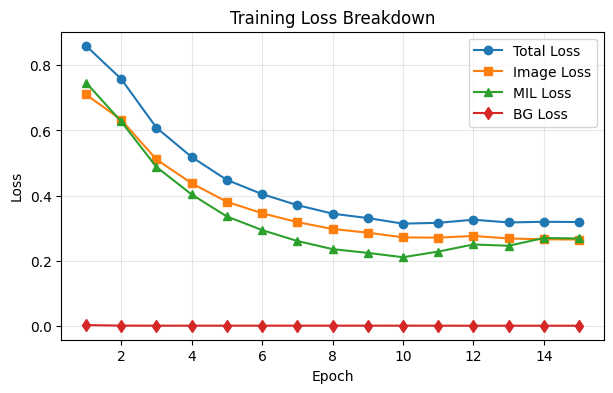

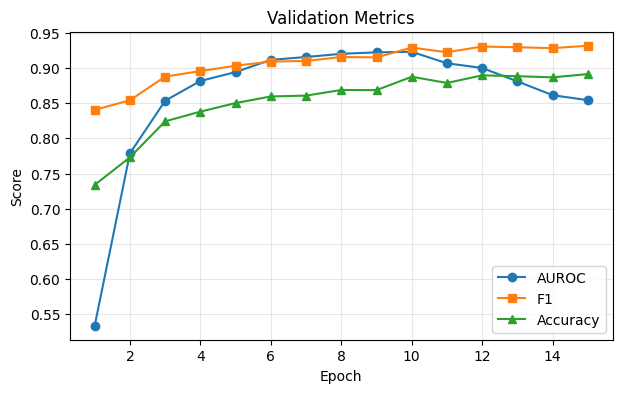

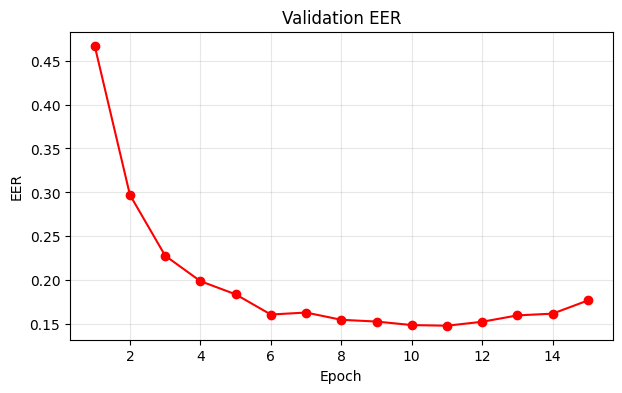

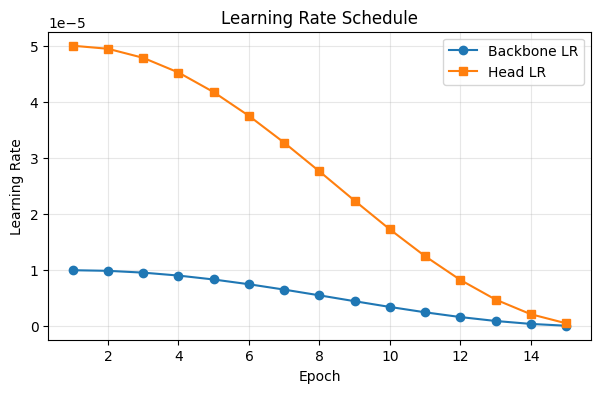

In [10]:
plot_loc(
    train_loss_list,
    train_img_loss_list,
    train_mil_loss_list,
    train_bg_loss_list,
    val_auc_list,
    val_f1_list,
    val_acc_list,
    val_eer_list,
    lr_backbone_list,
    lr_head_list
)


In [11]:
print("Final FF++ C23 Localisation Fine-Tune Results")
print(f"AUROC: {test_auc:.3f}")
print(f"F1-score: {test_f1:.3f}")
print(f"EER: {test_eer:.3f}")
print(f"Accuracy: {test_acc:.3f}")


Final FF++ C23 Localisation Fine-Tune Results
AUROC: 0.917
F1-score: 0.915
EER: 0.155
Accuracy: 0.867


## 10. Qualitative Localisation Analysis
This section visualises representative examples from the validation and test sets, including:
- correctly detected real faces
- strongly localised fake faces
- fake faces with weaker coverage
- failure cases

This provides a qualitative view of where the model places manipulation evidence.


In [12]:
def show_loc_examples(
    model,
    loader,
    class_to_idx,
    n_real_ok=2,
    n_best_fake=2,
    n_weak_fake=2,
    n_fail=2,
    alpha=0.85
):
    device = next(model.parameters()).device
    model.eval()
    fake_idx = class_to_idx["fake"]
    bg_idx = 19

    real_ok = []
    best_fake = []
    weak_fake = []
    fail = []

    with torch.no_grad():
        for batch in loader:
            x_rgb, x_raw, masks, lbls = batch

            x_rgb = x_rgb.to(device)
            x_raw = x_raw.to(device)
            masks = masks.to(device)
            lbls = lbls.to(device)

            image_logits, region_logits, aux = model(
                x_rgb, x_raw, masks,
                return_regions=True,
                return_aux=True
            )

            probs = torch.softmax(image_logits, dim=1)
            preds = probs.argmax(dim=1)
            region_fake_all = torch.softmax(region_logits, dim=-1)[:, :, fake_idx].cpu().numpy()

            for i in range(x_rgb.size(0)):
                img = denorm_rgb_tensor(x_rgb[i])
                mask_np = masks[i].detach().cpu().numpy()
                region_fake = region_fake_all[i].copy()
                p_fake = float(probs[i, fake_idx].item())

                gt = int(lbls[i].item())
                pred = int(preds[i].item())

                region_fake[0] = 0.0
                region_fake[bg_idx] = 0.0

                heat = np.zeros((img.shape[0], img.shape[1]), dtype=np.float32)
                for r in range(len(region_fake)):
                    mask_r = cv2.resize(
                        mask_np[r].astype(np.float32),
                        (img.shape[1], img.shape[0]),
                        interpolation=cv2.INTER_LINEAR
                    )
                    heat += region_fake[r] * mask_r

                heat = cv2.GaussianBlur(heat, (21, 21), 0)
                heat = heat - heat.min()
                heat = heat / (heat.max() + 1e-6)
                gated_heat = heat * p_fake

                if p_fake < 0.45:
                    soft = np.zeros_like(gated_heat)
                else:
                    soft = gated_heat.copy()
                    thr = max(0.20, np.quantile(soft, 0.60))
                    soft[soft < thr] = 0.0

                    if soft.max() > 0:
                        soft /= soft.max()

                    soft = cv2.GaussianBlur(soft, (21, 21), 0)
                    soft = np.clip(soft, 0, 1)

                coverage = (soft > 0.10).mean() * 100.0

                item = {
                    "img": img,
                    "gt": gt,
                    "pred": pred,
                    "p_fake": p_fake,
                    "soft": soft,
                    "gated_heat": gated_heat,
                    "coverage": coverage,
                }

                # Correct real
                if gt == pred and gt != fake_idx:
                    real_ok.append(item)

                # Correct fake
                elif gt == pred and gt == fake_idx:
                    best_score = 0.65 * p_fake + 0.35 * (coverage / 100.0)
                    weak_score = 0.80 * p_fake + 0.20 * (1.0 - coverage / 100.0)

                    item["best_score"] = best_score
                    item["weak_score"] = weak_score

                    best_fake.append(item)
                    weak_fake.append(item)

                # Failure
                else:
                    fail_margin = abs(p_fake - 0.5)
                    item["fail_margin"] = fail_margin
                    fail.append(item)

    # pick final examples
    real_ok = real_ok[:n_real_ok]
    best_fake = sorted(best_fake, key=lambda x: x["best_score"], reverse=True)[:n_best_fake]
    weak_fake = sorted(weak_fake, key=lambda x: x["weak_score"], reverse=True)[:n_weak_fake]
    fail = sorted(fail, key=lambda x: x["fail_margin"])[:n_fail]

    all_items = (
        [("Correct real", x) for x in real_ok] +
        [("Best fake localisation", x) for x in best_fake] +
        [("Weak fake coverage", x) for x in weak_fake] +
        [("Failure", x) for x in fail]
    )

    rows = len(all_items)
    fig, axes = plt.subplots(rows, 3, figsize=(12, 3.8 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, 0)

    for i, (group_name, item) in enumerate(all_items):
        img = item["img"]
        soft = item["soft"]
        gated_heat = item["gated_heat"]
        p_fake = item["p_fake"]
        coverage = item["coverage"]

        overlay = img.copy()
        red = np.zeros_like(img)
        red[..., 0] = 1.0

        alpha_map = (alpha * soft)[..., None]
        overlay = (1 - alpha_map) * overlay + alpha_map * red
        overlay = np.clip(overlay, 0, 1)

        gt_name = "fake" if item["gt"] == fake_idx else "real"
        pred_name = "fake" if item["pred"] == fake_idx else "real"
        color = "#2ecc71" if item["gt"] == item["pred"] else "#e74c3c"

        axes[i, 0].imshow(img)
        axes[i, 0].set_title(
            f"{group_name}\nGT={gt_name} | Pred={pred_name} | P(fake)={p_fake:.2f}",
            fontsize=9,
            color=color,
            fontweight="bold"
        )
        axes[i, 0].axis("off")

        axes[i, 1].imshow(gated_heat, cmap="jet", vmin=0, vmax=1)
        axes[i, 1].set_title("Region heatmap")
        axes[i, 1].axis("off")

        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title(f"Fake area | Coverage={coverage:.1f}%")
        axes[i, 2].axis("off")

    plt.tight_layout()
    plt.show()


In [13]:
FF_C40_ALIGNED_ROOT = Path("/kaggle/input/datasets/hooriyamasood/ffc40-aligned/kaggle/working/FFc40_aligned_faces")
FF_C40_MASK_ROOT    = Path("/kaggle/working/FF_C40_semantic_masks_20r")


Showing FF++ localisation examples from validation set...


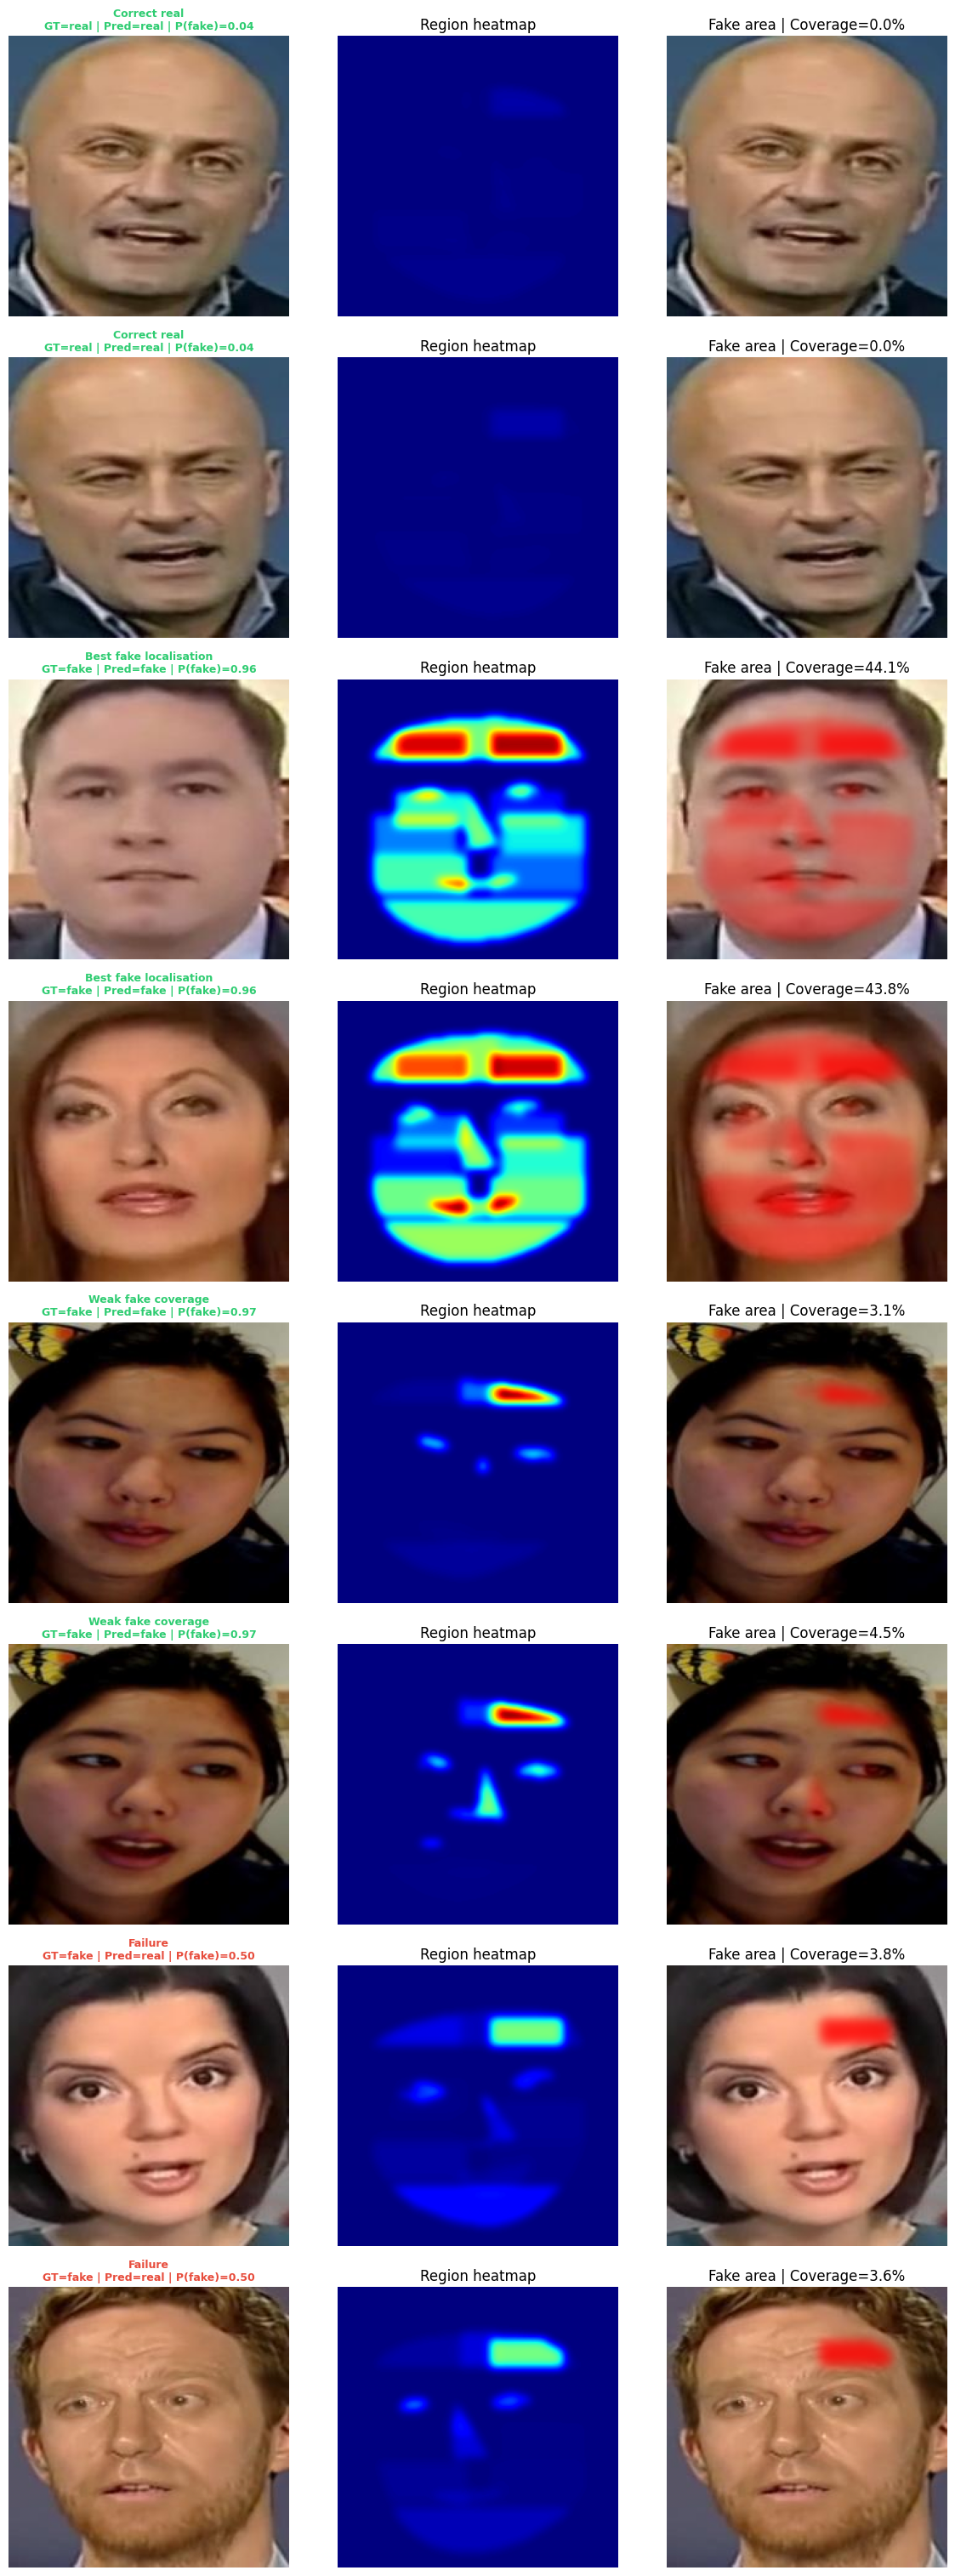


Showing FF++ localisation examples from test set...


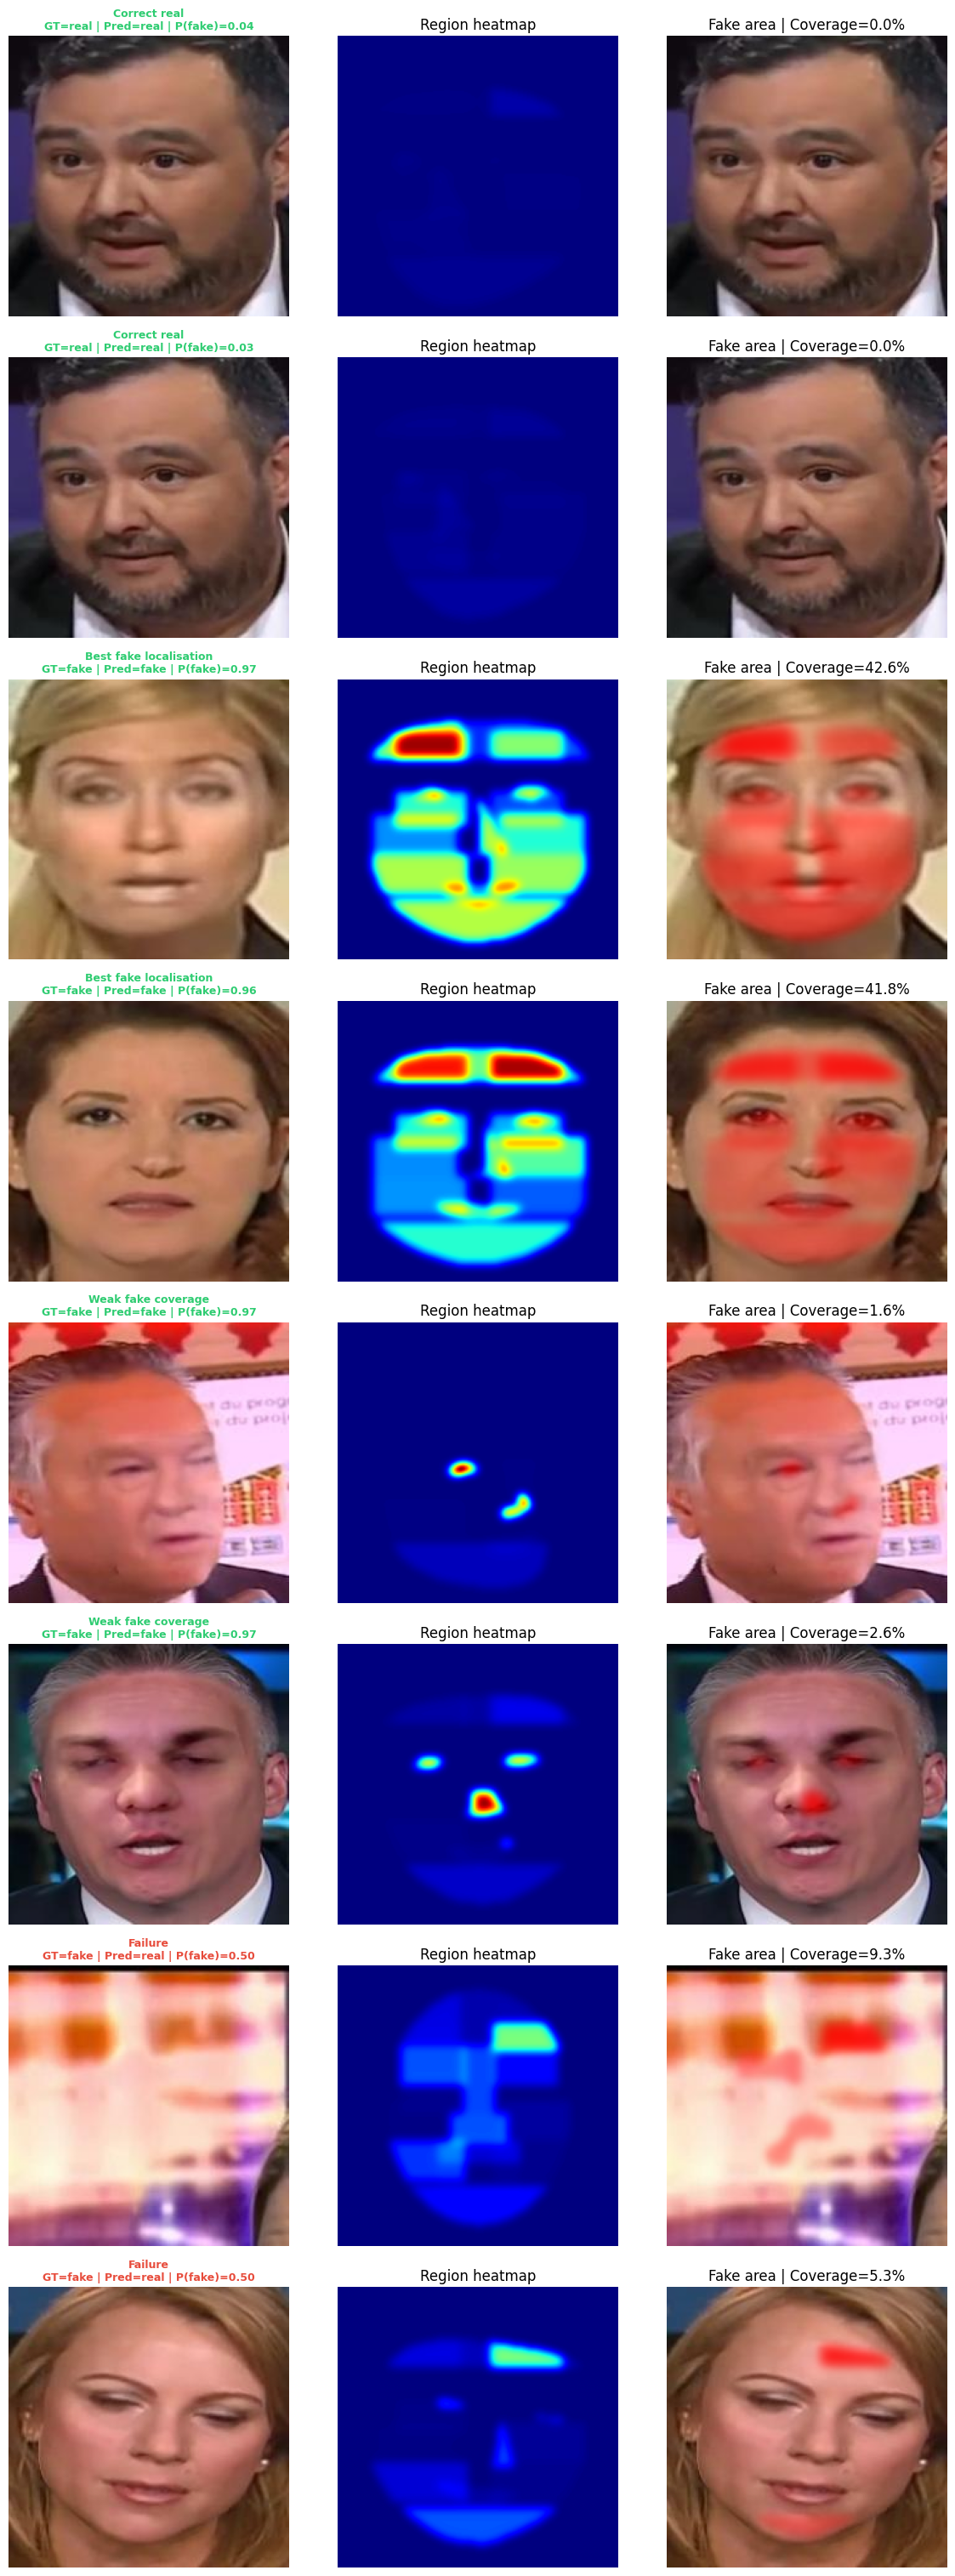

In [14]:
print("\nShowing FF++ localisation examples from validation set...")
show_loc_examples(
    model_ft,
    valloader_ft,
    class_to_idx_ft,
    n_real_ok=2,
    n_best_fake=2,
    n_weak_fake=2,
    n_fail=2,
    alpha=0.85
)

print("\nShowing FF++ localisation examples from test set...")
show_loc_examples(
    model_ft,
    testloader_ft,
    class_to_idx_ft,
    n_real_ok=2,
    n_best_fake=2,
    n_weak_fake=2,
    n_fail=2,
    alpha=0.85
)


## 11. Cross-Dataset Evaluation on FF++ C40
To assess generalisation, the best fine-tuned C23 localisation checkpoint is evaluated on FF++ C40. This tests performance under heavier compression and helps reveal how robust both classification and localisation behaviour remain outside the fine-tuning domain.


In [15]:
def evaluate_crossdataset(model, img_root, mask_root, batch_size=16, tag="FF++ EVAL", show_progress=False):

    rgb_norm = transforms.Normalize([0.485, 0.456, 0.406],
                                    [0.229, 0.224, 0.225])

   
    testset = FFPPMaskDataset(
        img_root=Path(img_root) / "test",
        mask_root=Path(mask_root) / "test",
        train=False,
        p_flip=0.0,
        jpeg_aug=None,
        rgb_color_aug=None,
        rgb_norm=rgb_norm,
        verbose=False
    )


    testloader = DataLoader(
        testset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    device = next(model.parameters()).device
    fake_idx = testset.class_to_idx["fake"]

    model.eval()
    y_true, y_prob = [], []

    with torch.no_grad():
        for x_rgb, x_raw, masks, lbls in tqdm(testloader, desc=tag, ncols=100, disable=not show_progress):

            x_rgb = x_rgb.to(device, non_blocking=True)
            x_raw = x_raw.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)

            logits = model(x_rgb, x_raw, masks)
            probs_fake = torch.softmax(logits, dim=1)[:, fake_idx].cpu().numpy()

            lbls_np = lbls.numpy()
            y_true.extend((lbls_np == fake_idx).astype(np.int32))
            y_prob.extend(probs_fake)

    auc, f1, eer, acc = calc_metrics(np.array(y_true), np.array(y_prob))
    print(f"{tag} → AUROC={auc:.3f} | F1={f1:.3f} | EER={eer:.3f} | ACC={acc:.3f}")
    return auc, f1, eer, acc

In [16]:
print("\nReloading best fine-tuned C23 checkpoint...")
_ = model_ft.load_state_dict(torch.load("/kaggle/working/best_ffpp_mask_finetune.pth", map_location=device))
_ = model_ft.eval()

print("\nGenerating C40 semantic masks...")
generate_masks(FF_C40_ALIGNED_ROOT, FF_C40_MASK_ROOT, show_progress=False)
print("C40 semantic masks generated.")

print("\nRunning cross-dataset evaluation on FF++ C40...")
c40_auc, c40_f1, c40_eer, c40_acc = evaluate_crossdataset(
    model_ft,
    img_root=FF_C40_ALIGNED_ROOT,
    mask_root=FF_C40_MASK_ROOT,
    batch_size=16,
    tag="FF++ C40 CROSS-DATASET",
    show_progress=False
)

print("\nFinal FF++ C40 Cross-Dataset Results")
print(f"AUROC: {c40_auc:.3f}")
print(f"F1-score: {c40_f1:.3f}")
print(f"EER: {c40_eer:.3f}")
print(f"Accuracy: {c40_acc:.3f}")



Reloading best fine-tuned C23 checkpoint...

Generating C40 semantic masks...
Saved: 50000
Failed: 0
Sample failures: []
C40 semantic masks generated.

Running cross-dataset evaluation on FF++ C40...
FF++ C40 CROSS-DATASET → AUROC=0.699 | F1=0.716 | EER=0.351 | ACC=0.619

Final FF++ C40 Cross-Dataset Results
AUROC: 0.699
F1-score: 0.716
EER: 0.351
Accuracy: 0.619


## 12. Result Summary
The localisation fine-tuned model achieved strong performance on FF++ C23 and showed reduced but still meaningful performance on FF++ C40 under cross-dataset evaluation.

This supports the claim that semantic-region guidance improves interpretability while maintaining strong detection capability.


## 13. Conclusion
This notebook demonstrates that the semantic-region Stage 3 model can be successfully fine-tuned on FF++ C23 for both detection and localisation. In addition to strong quantitative performance, the model provides interpretable region-level evidence through semantic heatmaps and coverage-based overlays.

Cross-dataset evaluation on FF++ C40 further shows how localisation quality and classification performance change under stronger compression.
